In [1]:
#Multiple Linear Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#Loaad the dataset
df = pd.read_csv('Oil_Well.csv')
x = df.iloc[:, [5, 8]].values
y = df.iloc[:, 1].values

In [3]:
df

,Date,\nOil volume (m3/day),Volume of liquid (m3/day),\nGas volume (m3/day),Water volume (m3/day),Water cut (%),\nWorking hours,\nDynamic level (m),\nReservoir pressure (atm)
0,1/1/2013,49,70,13055,21,29,24,1819,214
1,1/2/2013,49,70,13055,21,29,24,1836,214
2,1/3/2013,49,70,13055,21,29,24,1788,214
3,1/4/2013,49,70,13055,21,29,24,1789,214
4,1/5/2013,44,70,11768,26,36,24,1825,214
...,...,...,...,...,...,...,...,...,...
2934,1/14/2021,6,20,1593,15,70,16,2101,100
2935,1/15/2021,6,20,1593,15,70,16,2113,100
2936,1/16/2021,6,20,1583,14,70,16,2125,100
2937,1/17/2021,6,20,1573,14,70,16,2125,100


In [4]:
print(x)

[[ 29 214]
 [ 29 214]
 [ 29 214]
 ...
 [ 70 100]
 [ 70 100]
 [ 70 100]]


In [5]:
print (y)

[49 49 49 ...  6  6  5]


In [6]:
#Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
#Train the model
powei = LinearRegression()
powei.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
#Predict the test set results
y_pred = powei.predict(x_test)

In [9]:
#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rsme = np.sqrt(mse)

In [10]:
print (f"Coefficients : {powei.coef_}")


Coefficients : [-0.58445802  0.15453779]


In [11]:
print(f"Intercept : {powei.intercept_:.4f}")

Intercept : 34.6854


In [12]:
print(f"mse : {mse:.4f}")

mse : 4.9251


In [13]:
print(f"mae : {mae:.4f}")

mae : 1.6959


In [14]:

print(f"rmse : {rsme:.4f}")

rmse : 2.2193


In [15]:
print(f"r2_score : {r2:.4f}")

r2_score : 0.9476


C:\Users\USER\AppData\Local\Temp\ipykernel_25800\3266810136.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', color='red', lw=2)


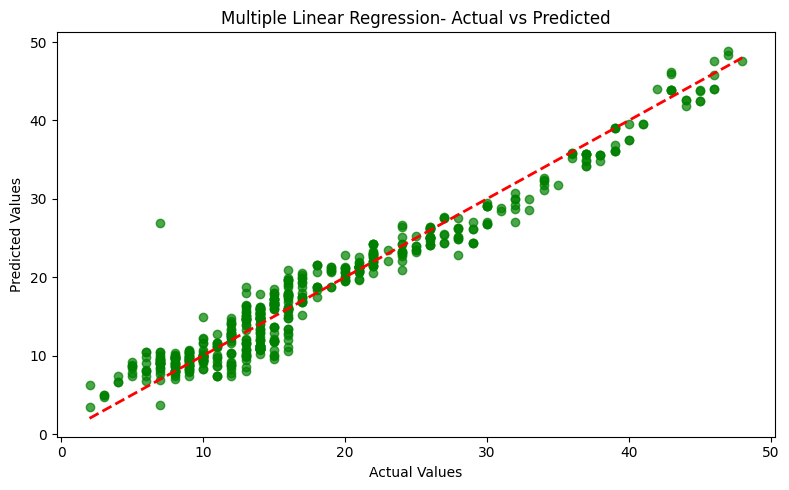

In [16]:
#Plot Actual vs Predicted values
plt.figure(figsize =(8, 5))
plt.scatter(y_test, y_pred, color='green', alpha = 0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multiple Linear Regression- Actual vs Predicted')
plt.tight_layout()
plt.savefig('Multiple_Linear_Regression.png')
plt.show()
